<div style="background:#123B63;color:white;padding:14px 18px;border-radius:6px">
<b>CSE 816 &mdash; Machine Learning Lab</b> &nbsp;&middot;&nbsp; Department of CSE, University of Chittagong<br>
<span style="font-size:90%">Module 1 &middot; Week 3 &middot; Part 4 of 4 &nbsp;&middot;&nbsp; 60 minutes</span>
</div>

# Overfitting and Regularization

Part 2 showed that polynomial features bend a decision boundary into any shape you like. This
part is the bill for that.

A model with enough flexibility will fit its training data perfectly and be worse than useless
on anything else. You will see it happen, learn to recognise the symptom in the fitted weights
before you have any test data, and add the penalty term that is the standard defence &mdash;
for linear and logistic regression alike.

**Companion theory lecture:** CSE 815, Week 3, Part 2 (Overfitting and Regularization).

## What you will be able to do

1. Produce underfitting and overfitting on demand, and tell them apart from numbers rather
   than pictures.
2. Recognise the symptom of overfitting in the fitted weights, before seeing any held-out data.
3. Implement the regularized cost and gradient for logistic regression.
4. Choose $\lambda$ from held-out performance, and describe the shape of the curve you get.
5. Explain, with a demonstration, why the bias $b$ is left out of the penalty.
6. Show what regularization does for perfectly separable data, where the unregularized fit does
   not exist.
7. Map your $\lambda$ onto `scikit-learn`'s `C`.

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

np.set_printoptions(precision=4, suppress=True)

BLUE, TEAL, AMBER, ROSE, GRAY = "#123B63", "#1B7F79", "#C97B17", "#9B2C4B", "#4A5560"


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out[()] if out.ndim == 0 else out


def compute_cost(X, y, w, b, eps=1e-12):
    f = np.clip(sigmoid(X @ w + b), eps, 1 - eps)
    return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))


def compute_gradient(X, y, w, b):
    err = sigmoid(X @ w + b) - y
    return X.T @ err / len(y), float(err.mean())


def accuracy(X, y, w, b, threshold=0.5):
    return float(((sigmoid(X @ w + b) >= threshold) == y).mean())


def load_rings(seed=3, m=160):
    """Positive class is a disc of radius 1.15, with 6% of the labels flipped."""
    rng = np.random.default_rng(seed)
    radius = np.sqrt(rng.uniform(0, 4.0, m))
    angle = rng.uniform(0, 2 * np.pi, m)
    X = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
    y = (radius < 1.15).astype(float)
    flip = rng.random(m) < 0.06
    y[flip] = 1 - y[flip]
    return np.round(X, 3), y


def poly_features(X, degree):
    """Every monomial x1^a * x2^c with 1 <= a + c <= degree."""
    cols = []
    for total in range(1, degree + 1):
        for i in range(total + 1):
            cols.append((X[:, 0] ** (total - i)) * (X[:, 1] ** i))
    return np.column_stack(cols)


X_ring, y_ring = load_rings()
rng = np.random.default_rng(0)
idx = rng.permutation(len(y_ring))
train, held = idx[:70], idx[70:]
print(f"rings: {len(y_ring)} points -> {len(train)} training, {len(held)} held out")
print(f"positive fraction: {y_ring.mean():.4f}")
print("\nfeature counts by degree:")
for d in [1, 2, 3, 6, 10]:
    print(f"  degree {d:2d}: {poly_features(X_ring, d).shape[1]:3d} features")

rings: 160 points -> 70 training, 90 held out
positive fraction: 0.3375

feature counts by degree:
  degree  1:   2 features
  degree  2:   5 features
  degree  3:   9 features
  degree  6:  27 features
  degree 10:  65 features


> **The held-out set is the whole point.** Everything before this part was measured on the data
> the model was fitted to. From here on, that number is evidence of almost nothing: it can be
> driven to perfection by a model that has learned nothing generalisable. Split first, fit on
> the training part only, and keep the held-out part untouched until you are ready to be judged.

---

## 2. Overfitting, produced on demand

Fit the same data with polynomial features of increasing degree. Scale the features &mdash;
Week 2's lesson, and mandatory here, since $x^{10}$ ranges over ten decades.

In [2]:
def gradient_descent(X, y, alpha, num_iters, lambda_=0.0):
    """Batch gradient descent on the (optionally regularized) logistic cost."""
    w, b = np.zeros(X.shape[1]), 0.0
    m = len(y)
    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        dj_dw = dj_dw + (lambda_ / m) * w        # b is deliberately absent -- see section 5
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
    return w, b


def fit_degree(degree, lambda_=0.0, alpha=0.5, num_iters=60000):
    """Build polynomial features, scale on the TRAINING split only, fit, and report."""
    P = poly_features(X_ring, degree)
    mu, sigma = P[train].mean(axis=0), P[train].std(axis=0)
    sigma[sigma == 0] = 1.0
    P_tr, P_he = (P[train] - mu) / sigma, (P[held] - mu) / sigma
    w, b = gradient_descent(P_tr, y_ring[train], alpha, num_iters, lambda_)
    return {
        "degree": degree, "n_features": P.shape[1], "w": w, "b": b,
        "train_acc": accuracy(P_tr, y_ring[train], w, b),
        "held_acc": accuracy(P_he, y_ring[held], w, b),
        "train_J": compute_cost(P_tr, y_ring[train], w, b),
        "held_J": compute_cost(P_he, y_ring[held], w, b),
        "max_w": float(np.abs(w).max()), "norm_w": float(np.linalg.norm(w)),
        "scaler": (mu, sigma),
    }


degrees = [1, 2, 3, 6, 10]
fits = [fit_degree(d) for d in degrees]

print(f"{'degree':>7} {'features':>9} {'train acc':>10} {'held acc':>9} "
      f"{'train J':>9} {'held J':>9} {'max |w|':>9}")
print("-" * 68)
for r in fits:
    print(f"{r['degree']:7d} {r['n_features']:9d} {r['train_acc']:10.4f} {r['held_acc']:9.4f} "
          f"{r['train_J']:9.4f} {r['held_J']:9.4f} {r['max_w']:9.3f}")

 degree  features  train acc  held acc   train J    held J   max |w|
--------------------------------------------------------------------
      1         2     0.7000    0.6333    0.5957    0.6899     0.384
      2         5     0.9143    0.8667    0.3048    0.4728     2.907
      3         9     0.9000    0.8222    0.2505    0.7751     5.308
      6        27     0.9857    0.7667    0.0772    1.7749    21.343
     10        65     0.9857    0.7556    0.0520    1.6443    19.088


Read the two accuracy columns against each other.

- **Degree 1** is *underfitting*: both numbers are bad, and they are bad together. A straight
  line cannot describe a disc, and no amount of data or training would help.
- **Degree 2** is right. Held-out accuracy peaks here, and the gap to training accuracy is
  small.
- **Degrees 6 and 10** are *overfitting*: training accuracy climbs towards 1, held-out accuracy
  falls. The model is describing the 6% of flipped labels, which are noise, as if they were
  signal.

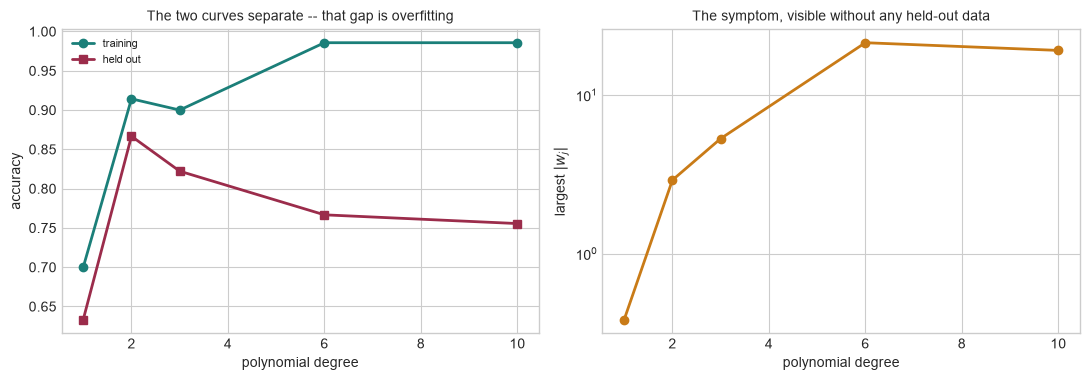

The right-hand panel is the practical point. The largest weight grows from
2.91 at degree 2 to 21.3 at degree 6.
Enormous weights that nearly cancel are the signature of a model contorting
itself through individual points -- and you can see them before you have any
held-out data at all.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

axes[0].plot(degrees, [r["train_acc"] for r in fits], "o-", c=TEAL, lw=2, label="training")
axes[0].plot(degrees, [r["held_acc"] for r in fits], "s-", c=ROSE, lw=2, label="held out")
axes[0].set_xlabel("polynomial degree")
axes[0].set_ylabel("accuracy")
axes[0].set_title("The two curves separate -- that gap is overfitting", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(degrees, [r["max_w"] for r in fits], "o-", c=AMBER, lw=2)
axes[1].set_xlabel("polynomial degree")
axes[1].set_ylabel("largest $|w_j|$")
axes[1].set_yscale("log")
axes[1].set_title("The symptom, visible without any held-out data", fontsize=10)
plt.tight_layout()
plt.show()

print("The right-hand panel is the practical point. The largest weight grows from")
print(f"{fits[1]['max_w']:.2f} at degree 2 to {fits[3]['max_w']:.1f} at degree 6.")
print("Enormous weights that nearly cancel are the signature of a model contorting")
print("itself through individual points -- and you can see them before you have any")
print("held-out data at all.")

assert fits[-1]["train_acc"] > fits[1]["train_acc"]
assert fits[-1]["held_acc"] < fits[1]["held_acc"]

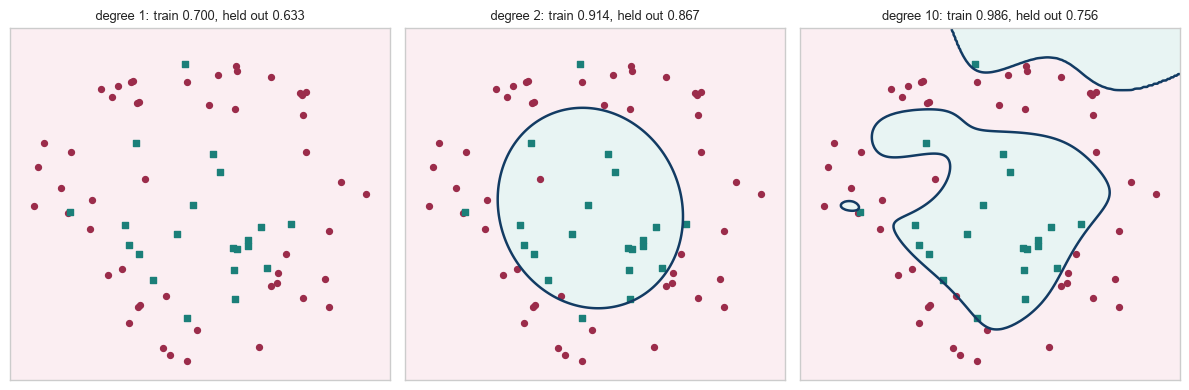

Left: too rigid. Middle: about right. Right: the boundary has grown fingers
that reach out to individual training points -- and those fingers are exactly
what fails on data the model has not seen.


In [4]:
def plot_boundary(ax, w, b, scaler, degree, title, lim=2.2):
    mu, sigma = scaler
    g = np.linspace(-lim, lim, 220)
    G1, G2 = np.meshgrid(g, g)
    grid = np.column_stack([G1.ravel(), G2.ravel()])
    P = (poly_features(grid, degree) - mu) / sigma
    Z = sigmoid(P @ w + b).reshape(G1.shape)
    ax.contourf(G1, G2, Z, levels=[0, 0.5, 1], colors=["#FBEEF2", "#E8F4F3"])
    ax.contour(G1, G2, Z, levels=[0.5], colors=[BLUE], linewidths=1.8)
    for label, colour, marker in [(0.0, ROSE, "o"), (1.0, TEAL, "s")]:
        sel = y_ring[train] == label
        ax.scatter(X_ring[train][sel, 0], X_ring[train][sel, 1], c=colour, marker=marker, s=18)
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(12, 4.0))
for ax, r in zip(axes, [fits[0], fits[1], fits[4]]):
    plot_boundary(ax, r["w"], r["b"], r["scaler"], r["degree"],
                  f"degree {r['degree']}: train {r['train_acc']:.3f}, held out {r['held_acc']:.3f}")
plt.tight_layout()
plt.show()

print("Left: too rigid. Middle: about right. Right: the boundary has grown fingers")
print("that reach out to individual training points -- and those fingers are exactly")
print("what fails on data the model has not seen.")

---

## 3. The regularized cost

Overfitting shows up as large weights, so penalise large weights:

$$J(\mathbf{w},b) = \underbrace{\frac1m\sum_{i=1}^m L\bigl(f^{(i)},y^{(i)}\bigr)}_{\text{fit the data}}
  \;+\; \underbrace{\frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2}_{\text{keep }\mathbf{w}\text{ small}}$$

$\lambda$ sets the exchange rate between the two. $\lambda = 0$ is what you have been doing;
$\lambda \to \infty$ drives every $w_j$ to zero and leaves a model that predicts the base rate
for everyone.

The gradient gains one term:

$$\frac{\partial J}{\partial w_j} = \frac1m\sum_i \bigl(f^{(i)}-y^{(i)}\bigr)x^{(i)}_j
  + \frac{\lambda}{m}w_j, \qquad
  \frac{\partial J}{\partial b} \ \text{unchanged}$$

Note $b$ is absent from both. Section 5 shows what happens if you forget that.

In [5]:
def compute_cost_reg(X, y, w, b, lambda_=0.0, eps=1e-12):
    """Logistic cost plus an L2 penalty on w. b is not penalised."""
    base = compute_cost(X, y, w, b, eps)
    return base + (lambda_ / (2 * len(y))) * float(np.sum(w ** 2))


def compute_gradient_reg(X, y, w, b, lambda_=0.0):
    dj_dw, dj_db = compute_gradient(X, y, w, b)
    return dj_dw + (lambda_ / len(y)) * w, dj_db


# Gradient check, with the penalty switched on.
P = poly_features(X_ring, 3)
mu3, sd3 = P[train].mean(axis=0), P[train].std(axis=0)
P_tr = (P[train] - mu3) / sd3
rng_c = np.random.default_rng(1)
w_t, b_t, lam_t = rng_c.normal(0, 0.4, P_tr.shape[1]), 0.2, 3.0

gw, gb = compute_gradient_reg(P_tr, y_ring[train], w_t, b_t, lam_t)
h = 1e-6
num = np.zeros_like(w_t)
for j in range(len(w_t)):
    e = np.zeros_like(w_t); e[j] = h
    num[j] = (compute_cost_reg(P_tr, y_ring[train], w_t + e, b_t, lam_t)
              - compute_cost_reg(P_tr, y_ring[train], w_t - e, b_t, lam_t)) / (2 * h)
num_b = (compute_cost_reg(P_tr, y_ring[train], w_t, b_t + h, lam_t)
         - compute_cost_reg(P_tr, y_ring[train], w_t, b_t - h, lam_t)) / (2 * h)

print("largest |analytic - numeric| over w:", np.abs(gw - num).max())
print("difference in b                    :", abs(gb - num_b))

assert np.allclose(gw, num, atol=1e-6)
assert np.isclose(gb, num_b, atol=1e-6)
print("\nRegularized gradient verified.")

largest |analytic - numeric| over w: 1.2368894797276653e-10
difference in b                    : 1.0269840533538854e-12

Regularized gradient verified.


### Reading the update as shrinkage

Substituting the new gradient into the update and collecting the $w_j$ terms:

$$w_j := w_j - \alpha\left[\frac1m\sum_i(f^{(i)}-y^{(i)})x_j^{(i)} + \frac{\lambda}{m}w_j\right]
       = \underbrace{\left(1 - \frac{\alpha\lambda}{m}\right)w_j}_{\text{shrink}}
         - \underbrace{\frac{\alpha}{m}\sum_i(f^{(i)}-y^{(i)})x_j^{(i)}}_{\text{the usual step}}$$

Every iteration multiplies each weight by a number slightly below 1 *before* taking the
ordinary step. Regularization is a small, constant leak out of every weight.

In [6]:
m_tr = len(train)
alpha = 0.5
print(f"{'lambda':>8} {'shrink factor 1 - alpha*lambda/m':>34} {'after 1000 iterations':>23}")
print("-" * 68)
for lam in [0.0, 1.0, 10.0, 100.0]:
    factor = 1 - alpha * lam / m_tr
    print(f"{lam:8.1f} {factor:34.6f} {factor ** 1000:23.6f}")

print("\nA weight receiving no gradient signal at all decays geometrically to zero.")
print("A weight the data genuinely supports reaches a balance: the leak per step")
print("equals the pull from the data.")

  lambda   shrink factor 1 - alpha*lambda/m   after 1000 iterations
--------------------------------------------------------------------
     0.0                           1.000000                1.000000
     1.0                           0.992857                0.000770
    10.0                           0.928571                0.000000
   100.0                           0.285714                0.000000

A weight receiving no gradient signal at all decays geometrically to zero.
A weight the data genuinely supports reaches a balance: the leak per step
equals the pull from the data.


---

## 4. Choosing $\lambda$

Take the degree-6 model &mdash; the one that overfitted badly &mdash; and sweep $\lambda$
without changing anything else.

In [7]:
def fit_degree_reg(degree, lambda_, alpha=0.5, num_iters=60000):
    P = poly_features(X_ring, degree)
    mu, sigma = P[train].mean(axis=0), P[train].std(axis=0)
    sigma[sigma == 0] = 1.0
    P_tr, P_he = (P[train] - mu) / sigma, (P[held] - mu) / sigma
    w, b = np.zeros(P_tr.shape[1]), 0.0
    mm = len(train)
    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient_reg(P_tr, y_ring[train], w, b, lambda_)
        w, b = w - alpha * dj_dw, b - alpha * dj_db
    return {
        "lambda": lambda_, "w": w, "b": b,
        "train_acc": accuracy(P_tr, y_ring[train], w, b),
        "held_acc": accuracy(P_he, y_ring[held], w, b),
        "max_w": float(np.abs(w).max()), "norm_w": float(np.linalg.norm(w)),
        "scaler": (mu, sigma),
    }


lambdas = [0.0, 0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
sweep = [fit_degree_reg(6, lam) for lam in lambdas]

print(f"{'lambda':>8} {'train acc':>10} {'held acc':>9} {'max |w|':>9} {'||w||':>9}")
print("-" * 50)
for r in sweep:
    print(f"{r['lambda']:8.2f} {r['train_acc']:10.4f} {r['held_acc']:9.4f} "
          f"{r['max_w']:9.3f} {r['norm_w']:9.3f}")

best = max(sweep, key=lambda r: r["held_acc"])
print(f"\nbest held-out accuracy {best['held_acc']:.4f} at lambda = {best['lambda']}")

  lambda  train acc  held acc   max |w|     ||w||
--------------------------------------------------
    0.00     0.9857    0.7667    21.343    47.316
    0.01     0.9429    0.8111     7.644    17.726
    0.10     0.9286    0.8222     2.369     6.447
    1.00     0.9143    0.8556     1.266     2.645
    3.00     0.9143    0.8556     0.767     1.608
   10.00     0.9286    0.8444     0.413     0.922
   30.00     0.8143    0.6889     0.220     0.524
  100.00     0.7000    0.6333     0.099     0.241

best held-out accuracy 0.8556 at lambda = 1.0


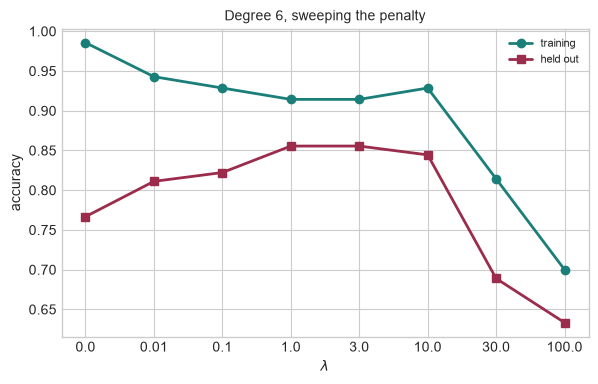

Left end (lambda = 0): high variance. Training accuracy is nearly perfect and
held-out accuracy is poor -- the model is fitting the noise.
Right end (lambda = 100): high bias. Both are poor together, the same failure
as degree 1 in section 2, reached from the other direction.
The best held-out accuracy sits in the middle, and it beats the unregularized
degree-6 model by 0.0889.


In [8]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
xs = np.arange(len(lambdas))
ax.plot(xs, [r["train_acc"] for r in sweep], "o-", c=TEAL, lw=2, label="training")
ax.plot(xs, [r["held_acc"] for r in sweep], "s-", c=ROSE, lw=2, label="held out")
ax.set_xticks(xs)
ax.set_xticklabels([str(l) for l in lambdas])
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("accuracy")
ax.set_title("Degree 6, sweeping the penalty", fontsize=10)
ax.legend(fontsize=8)
plt.show()

print("Left end (lambda = 0): high variance. Training accuracy is nearly perfect and")
print("held-out accuracy is poor -- the model is fitting the noise.")
print("Right end (lambda = 100): high bias. Both are poor together, the same failure")
print("as degree 1 in section 2, reached from the other direction.")
print("The best held-out accuracy sits in the middle, and it beats the unregularized")
print(f"degree-6 model by {best['held_acc'] - sweep[0]['held_acc']:.4f}.")

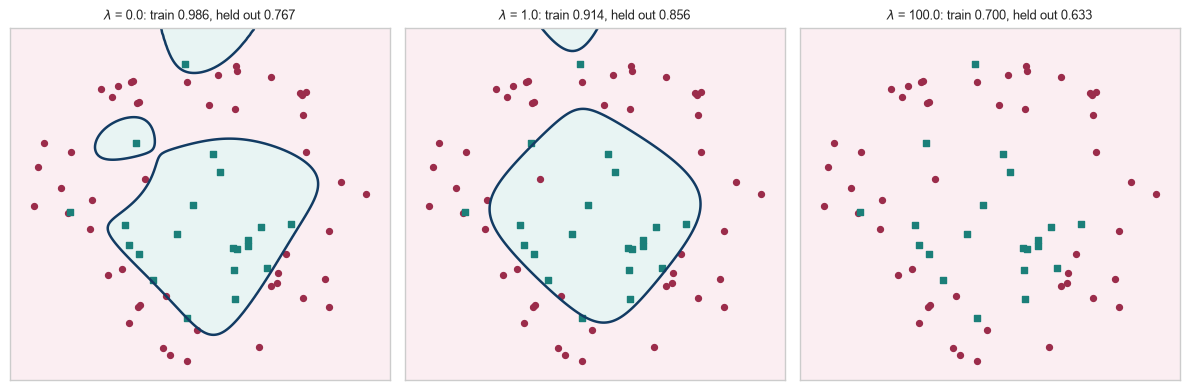

The same degree-6 model, three times. Only lambda differs. The fingers retract
as the penalty rises, and then the boundary flattens out altogether.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.0))
for ax, r in zip(axes, [sweep[0], best, sweep[-1]]):
    plot_boundary(ax, r["w"], r["b"], r["scaler"], 6,
                  f"$\\lambda$ = {r['lambda']}: train {r['train_acc']:.3f}, "
                  f"held out {r['held_acc']:.3f}")
plt.tight_layout()
plt.show()

print("The same degree-6 model, three times. Only lambda differs. The fingers retract")
print("as the penalty rises, and then the boundary flattens out altogether.")

### Checkpoint 1

`fit_degree_reg` reports held-out accuracy, but accuracy is a blunt instrument: it only counts
decisions and ignores how confident they were.

Extend the sweep to record the held-out **cost** as well, using `compute_cost` (the
*unregularized* cost &mdash; the penalty is a training device, not part of how you score a
model). Plot held-out cost against $\lambda$ and report the minimising $\lambda$.

*Expected:* held-out cost falls from about `1.7749` at $\lambda = 0$ to a minimum of about
`0.5126` at $\lambda = 10$, then rises again to about `0.5962` at $\lambda = 100$. Note that
this picks a **different** $\lambda$ from the accuracy criterion, which chose `1.0`; that is
the normal state of affairs. Say in one sentence which criterion you would trust for this
problem and why.

In [ ]:
# Your code here

---

## 5. Why $b$ is not penalised

The penalty sums over $j = 1, \ldots, n$ &mdash; the weights only. The bias is exempt, and it is
worth seeing what goes wrong if you forget.

$b$ sets the model's output when every feature is at its mean, so it carries the **base rate**.
Shrinking $b$ towards zero drags $g(b)$ towards $g(0) = \tfrac12$, which asserts that the two
classes are equally common. For a rare event that is badly wrong, and no amount of data will
argue the model out of it.

In [ ]:
def gd_penalise_everything(X, y, alpha, num_iters, lambda_):
    """WRONG on purpose: penalises b as well as w."""
    w, b = np.zeros(X.shape[1]), 0.0
    m = len(y)
    for _ in range(num_iters):
        err = sigmoid(X @ w + b) - y
        w = w - alpha * (X.T @ err / m + (lambda_ / m) * w)
        b = b - alpha * (float(err.mean()) + (lambda_ / m) * b)
    return w, b


def gd_correct(X, y, alpha, num_iters, lambda_):
    w, b = np.zeros(X.shape[1]), 0.0
    m = len(y)
    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient_reg(X, y, w, b, lambda_)
        w, b = w - alpha * dj_dw, b - alpha * dj_db
    return w, b


# A rare event: about 12% positive, one weak feature.
rng_r = np.random.default_rng(11)
m_rare = 200
X_rare = np.round(rng_r.normal(0, 1, m_rare), 3).reshape(-1, 1)
y_rare = (rng_r.random(m_rare) < sigmoid(-2.6 + 0.5 * X_rare[:, 0])).astype(float)
base_rate = y_rare.mean()
print(f"base rate: {base_rate:.4f}  ({int(y_rare.sum())} positive of {m_rare})\n")

print(f"{'lambda':>8} {'b (correct)':>12} {'g(b)':>9} {'b (b penalised)':>17} {'g(b)':>9}")
print("-" * 60)
for lam in [0.0, 1.0, 10.0, 100.0]:
    _, b_ok = gd_correct(X_rare, y_rare, 0.5, 40000, lam)
    _, b_bad = gd_penalise_everything(X_rare, y_rare, 0.5, 40000, lam)
    print(f"{lam:8.1f} {b_ok:12.4f} {float(sigmoid(np.array(b_ok))):9.4f} "
          f"{b_bad:17.4f} {float(sigmoid(np.array(b_bad))):9.4f}")

print(f"\nAs lambda grows, the correct model degenerates to 'always predict the base")
print(f"rate' -- g(b) heads for {base_rate:.4f}, which is right. The one that penalises b")
print("degenerates to 'always predict a coin flip', which is not. One extra term in")
print("one line of code, and a rare-event model becomes systematically over-confident.")

---

## 6. Regularization rescues the unfittable case

Part 2 mentioned in passing that a *perfectly separable* training set has no maximum-likelihood
fit. Here is the failure in full, and the repair.

If some $(\mathbf{w},b)$ separates the classes with no mistakes, then doubling it makes every
prediction more confident and every loss smaller, so $J(2\mathbf{w},2b) < J(\mathbf{w},b)$.
There is no minimum: the cost decreases forever along that ray, and gradient descent produces
weights that grow for as long as you let it run.

In [ ]:
# The screening set with the awkward 2 cm malignancy removed: now perfectly separable.
X_sep = np.array([[1.], [3], [4], [5], [6], [7], [8]])
y_sep = np.array([0., 0, 0, 0, 1, 1, 1])

print("no penalty:")
print(f"{'iterations':>12} {'w':>10} {'b':>10} {'boundary':>10} {'J':>10}")
print("-" * 56)
for iters in [1_000, 10_000, 100_000]:
    w_s, b_s = gd_correct(X_sep, y_sep, 0.2, iters, 0.0)
    print(f"{iters:12,} {w_s[0]:10.4f} {b_s:10.4f} {-b_s / w_s[0]:10.4f} "
          f"{compute_cost(X_sep, y_sep, w_s, b_s):10.6f}")

print("\nThe boundary settles almost immediately; the parameters never do. A solver that")
print("reports convergence here is reporting that it hit its iteration limit.\n")

print("with a penalty (100,000 iterations):")
print(f"{'lambda':>8} {'w':>10} {'b':>10} {'boundary':>10}")
print("-" * 42)
for lam in [0.1, 1.0, 10.0]:
    w_s, b_s = gd_correct(X_sep, y_sep, 0.2, 100_000, lam)
    print(f"{lam:8.2f} {w_s[0]:10.4f} {b_s:10.4f} {-b_s / w_s[0]:10.4f}")

w_none, _ = gd_correct(X_sep, y_sep, 0.2, 100_000, 0.0)
w_reg, _ = gd_correct(X_sep, y_sep, 0.2, 100_000, 1.0)
assert abs(w_reg[0]) < abs(w_none[0]) / 3
print("\nThe penalty supplies the finite optimum that the likelihood alone does not have.")
print("This is why scikit-learn regularizes by default: the unregularized problem is")
print("not always well posed, and you cannot tell from the data that it is not.")

---

## 7. scikit-learn: `C` is $1/\lambda$

`LogisticRegression` minimises

$$\tfrac12\mathbf{w}^{\mathsf{T}}\mathbf{w} + C\sum_{i=1}^m L\bigl(f^{(i)},y^{(i)}\bigr)$$

Divide through by $Cm$ and compare with our

$$\frac1m\sum_i L + \frac{\lambda}{2m}\mathbf{w}^{\mathsf{T}}\mathbf{w}$$

The two agree when $\lambda = 1/C$. **`C` is an inverse penalty:** small `C` means heavy
regularization, which is the opposite of the intuition the letter suggests.

In [ ]:
from sklearn.linear_model import LogisticRegression

P6 = poly_features(X_ring, 6)
mu6, sd6 = P6[train].mean(axis=0), P6[train].std(axis=0)
sd6[sd6 == 0] = 1.0
P6_tr = (P6[train] - mu6) / sd6
y_tr = y_ring[train]

print(f"{'lambda':>8} {'C = 1/lambda':>13} {'max |w| mine':>14} {'max |w| sklearn':>17} "
      f"{'max difference':>15}")
print("-" * 72)
for lam in [1.0, 10.0, 100.0]:
    w_mine, b_mine = gd_correct(P6_tr, y_tr, 0.5, 120000, lam)
    clf = LogisticRegression(C=1.0 / lam, max_iter=20000).fit(P6_tr, y_tr)
    print(f"{lam:8.1f} {1.0 / lam:13.4f} {np.abs(w_mine).max():14.4f} "
          f"{np.abs(clf.coef_[0]).max():17.4f} {np.abs(w_mine - clf.coef_[0]).max():15.2e}")

clf = LogisticRegression(C=1.0 / 10.0, max_iter=20000).fit(P6_tr, y_tr)
w_mine, b_mine = gd_correct(P6_tr, y_tr, 0.5, 120000, 10.0)
assert np.allclose(w_mine, clf.coef_[0], atol=5e-2)
print("\nYour regularized implementation and the library agree.")
print("sklearn does not penalise the intercept either -- section 5's rule is universal.")

### Checkpoint 2

The whole point of a held-out set is that you may look at it **once**, at the end. Sweeping
$\lambda$ against held-out accuracy, as section 4 did, quietly spends it: the chosen $\lambda$
is now tuned to those 90 points, and their accuracy is no longer an unbiased estimate of
anything.

Do it properly. Split the rings data three ways &mdash; 70 training, 45 validation, 45 test
&mdash; using `rng = np.random.default_rng(0)` and `idx = rng.permutation(160)` as above, with
`train = idx[:70]`, `valid = idx[70:115]`, `test = idx[115:]`.

1. Sweep $\lambda$ over `lambdas` for degree 6, choosing the value with the best **validation**
   accuracy.
2. Report that model's accuracy on the **test** split, which nothing has touched.
3. Compare the validation accuracy of the chosen model with its test accuracy, and say which of
   the two you would quote in a report.

*Expected:* the best validation accuracy is `0.8667`, attained at both $\lambda = 1.0$ and
$\lambda = 3.0$; taking the first, that model scores `0.8444` on the test split. Validation
flatters the model, but only by about two points &mdash; and with 45 points per split, two
points is four examples, which is well inside the noise. That is the real lesson: neither
number is precise enough to separate $\lambda = 1$ from $\lambda = 3$, and a single split
cannot tell you which to ship. Week 5 introduces cross-validation for exactly this reason.

In [ ]:
# Your code here

---

## 8. Recap

- Training accuracy alone is not evidence. Split the data, fit on the training part, and keep
  the rest untouched.
- Underfitting: both numbers bad, together. Overfitting: training good, held-out bad, and a
  widening gap between them.
- On the rings data, degree 6 reached `0.9857` training accuracy against `0.7667` held out;
  degree 2 reached `0.9143` and `0.8667`.
- The symptom is visible in the weights before you have any held-out data: the largest $|w_j|$
  grew from about `2.9` at degree 2 to over `20` at degree 6.
- Regularized cost: $J + \frac{\lambda}{2m}\sum_j w_j^2$; regularized gradient: add
  $\frac{\lambda}{m}w_j$. The update reads as a shrink by $(1 - \alpha\lambda/m)$ before every
  ordinary step.
- $\lambda$ trades variance against bias. Too small and you overfit; too large and you underfit
  in exactly the way degree 1 did. Choose it from held-out performance.
- **Never penalise $b$.** It carries the base rate, and shrinking it drags a rare-event model
  towards a coin flip.
- Regularization also supplies a finite optimum for perfectly separable data, where the
  unregularized likelihood has none.
- `scikit-learn`'s `C` is $1/\lambda$. Small `C`, heavy penalty.

### Exercises to hand in

1. Repeat the degree sweep with `load_rings(seed=7)` and a different train/held-out split.
   Report the degree that maximises held-out accuracy, and say whether your conclusion about
   degree 2 was a property of the data or of the split.
2. Set the label noise in `load_rings` to 0% and repeat section 2. Does degree 10 still
   overfit? Explain what changed, in terms of what the extra flexibility now has to fit.
3. Implement L1 regularization &mdash; penalty $\frac{\lambda}{m}\sum_j |w_j|$, with
   sub-gradient $\frac{\lambda}{m}\,\mathrm{sign}(w_j)$ &mdash; and repeat the $\lambda$ sweep at
   degree 6. Report how many weights are exactly zero at each $\lambda$, and contrast with L2.
4. Show empirically that the shrink factor is real: fit at $\lambda = 10$, then re-run with the
   gradient's data term forced to zero, and confirm the weights decay by
   $(1-\alpha\lambda/m)$ per iteration.
5. Regularize the bias deliberately, as in section 5, on the **loans** data from Part 3 (base
   rate about 0.525). Report how much damage it does there, and explain why it is so much less
   than in the rare-event example.
6. **Practice lab (assessed).** Using only the tools from Week 3, build the best classifier you
   can for `load_loans(seed=99, m=400)`: engineer features, scale them, choose the degree and
   $\lambda$ on a validation split, choose a threshold from a stated cost ratio, and report
   test-set performance once. Hand in the notebook plus one page justifying each choice,
   including the cost ratio you assumed and who you imagine bears each kind of error.

### Next

**Module 2, Week 1 &mdash; Neural Networks:** the logistic unit of this week becomes one neuron,
and stacking them lets the model learn its own features instead of being handed polynomial ones.

**Reading:** James et al., *ISL* 2e, &sect;6.2 (ridge and lasso) and &sect;2.2.2 (the
bias--variance trade-off); Bishop, *PRML*, &sect;4.3.2 for the separability problem.